In [ ]:
# ============================================================
# 1. USER SETTINGS
# ============================================================

from google.colab import drive
drive.mount("/content/drive")

import os
import math
import pickle
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import differential_evolution

warnings.filterwarnings("ignore")

plt.rcParams["figure.dpi"] = 130
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 10

# ============================================================
# PATHS
# ============================================================

BASE_DIR = (
    "/content/drive/MyDrive/Colab Notebooks/"
    "UTB_CommunityGeothermal/Data_submission"
)

LOAD_XLSX_PATH = os.path.join(BASE_DIR, "LOAD.xlsx")

OUT_DIR = (
    "/content/drive/MyDrive/Colab Notebooks/"
    "UTB_CommunityGeothermal/multicase_rom_results"
)

os.makedirs(OUT_DIR, exist_ok=True)

# ============================================================
# TIME CONSTANTS
# ============================================================

DT_H = 3600.0
HOURS_PER_YEAR = 365.25 * 24.0
SECONDS_PER_YEAR = 365.25 * 24.0 * 3600.0
CALIB_YEARS = 3.0

# ============================================================
# DIFFERENTIAL EVOLUTION SETTINGS
# ============================================================

# Use TEST_MODE=True first for quick checking.
# For final manuscript-quality results, set TEST_MODE=False.
TEST_MODE = False


if TEST_MODE:
    N_SEEDS = 3
    MAXITER = 500
    POPSIZE = 15
else:
    N_SEEDS = 10
    MAXITER = 1000
    POPSIZE = 20

DE_TOL = 1e-7

# ============================================================
# CASE CONFIGURATION
# ============================================================
# IMPORTANT:
# Final multi-case analysis uses the original case-specific
# UTB_prop_dim.dat forcing files, not repeated LOAD.xlsx profiles.
#
# LOAD.xlsx may be used only for inspection/verification of annual load profiles.
# The forcing used for calibration/evaluation should match the forcing used
# in the high-fidelity UTB simulation.

CASE_CONFIGS = [
    {
        "case": "Orlando",
        "response_path": os.path.join(
            BASE_DIR,
            "ppt_page11-13_5yr_Orlando",
            "T_UTB 5.dat",
        ),
        "load_path": os.path.join(
            BASE_DIR,
            "ppt_page11-13_5yr_Orlando",
            "UTB_prop_dim.dat",
        ),
    },
    {
        "case": "Knoxville",
        "response_path": os.path.join(
            BASE_DIR,
            "ppt_page24_Knoxville",
            "T_UTB 1.dat",
        ),
        "load_path": os.path.join(
            BASE_DIR,
            "ppt_page24_Knoxville",
            "UTB_prop_dim.dat",
        ),
    },
]

# ============================================================
# PATH CHECKS
# ============================================================

print("BASE_DIR exists:", os.path.exists(BASE_DIR))
print("LOAD_XLSX exists:", os.path.exists(LOAD_XLSX_PATH))
print("OUT_DIR:", OUT_DIR)

print("\nCase file checks:")
for cfg in CASE_CONFIGS:
    print("-" * 80)
    print("Case:", cfg["case"])
    print("Response path:", cfg["response_path"])
    print("Response exists:", os.path.exists(cfg["response_path"]))
    print("Load path:", cfg["load_path"])
    print("Load exists:", os.path.exists(cfg["load_path"]))


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
BASE_DIR exists: True
LOAD_XLSX exists: True
OUT_DIR: /content/drive/MyDrive/Colab Notebooks/UTB_CommunityGeothermal/multicase_rom_results

Case file checks:
--------------------------------------------------------------------------------
Case: Orlando
Response path: /content/drive/MyDrive/Colab Notebooks/UTB_CommunityGeothermal/Data_submission/ppt_page11-13_5yr_Orlando/T_UTB 5.dat
Response exists: True
Load path: /content/drive/MyDrive/Colab Notebooks/UTB_CommunityGeothermal/Data_submission/ppt_page11-13_5yr_Orlando/UTB_prop_dim.dat
Load exists: True
--------------------------------------------------------------------------------
Case: Knoxville
Response path: /content/drive/MyDrive/Colab Notebooks/UTB_CommunityGeothermal/Data_submission/ppt_page24_Knoxville/T_UTB 1.dat
Response exists: True
Load path: /content/drive/MyDrive/Colab Notebooks/UTB_CommunityGeot

In [ ]:
# ============================================================
# 2. LOAD.XLSX CLEAN PARSER
# NOTE:
# This parser is kept for inspecting LOAD.xlsx only.
# Final multi-case analysis uses the original case-specific UTB_prop_dim.dat forcing files.
# ============================================================

def parse_city_load_sheet_clean(xlsx_path, sheet_name):
    """
    Parse a city load sheet from LOAD.xlsx.

    The workbook has metadata rows followed by a table:
    Time | Thermal load | Fluid flow | Outlet temperature | Far field ground temperature | Load

    Important:
    - The Excel Time column is not used as the simulation time axis.
    - The row index is used as the hourly index.
    - Rows with missing Time / missing Thermal load are dropped.
    - The 'Load' column is used as forcing in W.
    """
    raw = pd.read_excel(xlsx_path, sheet_name=sheet_name, header=None)

    header_row = None

    for i in range(len(raw)):
        row_vals = raw.iloc[i].astype(str).str.strip().str.lower().tolist()

        if "time" in row_vals and "load" in row_vals:
            header_row = i
            break

    if header_row is None:
        raise ValueError(f"Could not find header row in sheet {sheet_name}")

    headers = raw.iloc[header_row].tolist()

    # Data starts two rows below header:
    # header row = names
    # next row = units
    # then data
    data = raw.iloc[header_row + 2:].copy()
    data.columns = headers

    data = data.dropna(axis=1, how="all")
    data = data.dropna(axis=0, how="all").reset_index(drop=True)

    data.columns = [str(c).strip() for c in data.columns]

    expected_cols = [
        "Time",
        "Thermal load",
        "Fluid flow",
        "Outlet temperature",
        "Far field ground temperature",
        "Load",
    ]

    existing_cols = [c for c in expected_cols if c in data.columns]
    data = data[existing_cols].copy()

    for col in data.columns:
        if col != "Time":
            data[col] = pd.to_numeric(data[col], errors="coerce")

    # Drop fake/helper rows at the bottom
    data = data.dropna(subset=["Time", "Load"]).copy()

    if "Thermal load" in data.columns:
        data = data.dropna(subset=["Thermal load"]).copy()

    data = data.reset_index(drop=True)

    # Reliable hourly time axis
    data["hour_index"] = np.arange(len(data), dtype=int)
    data["time_s"] = data["hour_index"].astype(float) * 3600.0
    data["time_day"] = data["time_s"] / 86400.0
    data["time_year"] = data["time_s"] / SECONDS_PER_YEAR

    # ROM forcing
    data["load"] = data["Load"]
    data["case"] = sheet_name

    return data


# Inspect cleaned city loads
city_load_summaries = []

for cfg in CASE_CONFIGS:
    df_load = parse_city_load_sheet_clean(LOAD_XLSX_PATH, cfg["load_sheet"])

    city_load_summaries.append({
        "case": cfg["case"],
        "sheet": cfg["load_sheet"],
        "n_rows": len(df_load),
        "time_span_years": df_load["time_year"].max() - df_load["time_year"].min(),
        "load_min_W": df_load["load"].min(),
        "load_max_W": df_load["load"].max(),
        "load_mean_W": df_load["load"].mean(),
        "load_std_W": df_load["load"].std(ddof=0),
    })

city_load_summary_df = pd.DataFrame(city_load_summaries)
display(city_load_summary_df)

city_load_summary_path = os.path.join(OUT_DIR, "city_load_summary.csv")
city_load_summary_df.to_csv(city_load_summary_path, index=False)

print("Saved:", city_load_summary_path)


KeyError: 'load_sheet'

In [ ]:
# ============================================================
# 3. THERMAL RESPONSE LOADING AND COMMON-GRID PREPROCESSING
# ============================================================

def load_raw_tutb(path):
    """
    Load raw T_UTB *.dat thermal-response file.

    Expected six columns:
        time_s, T_water, T_3, T_34, q_tough_temp, T_45

    The raw files contain repeated timestamps; these are handled later
    by collapse_tutb_unique().
    """
    cols = [
        "time_s",
        "T_water",
        "T_3",
        "T_34",
        "q_tough_temp",
        "T_45",
    ]

    df = pd.read_csv(
        path,
        sep=r"\s+",
        header=None,
        names=cols,
        engine="python",
    )

    for c in cols:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    df = df.dropna(subset=["time_s"]).reset_index(drop=True)

    df["time_day"] = df["time_s"] / 86400.0
    df["time_year"] = df["time_s"] / SECONDS_PER_YEAR

    return df


def collapse_tutb_unique(df):
    """
    Collapse repeated thermal-response timestamps to unique time_s values.

    Repeated timestamps occur in the raw simulation export. For each repeated
    timestamp, thermal-response variables are averaged. This produces a
    monotonic nonuniform thermal-response series suitable for interpolation
    onto the hourly forcing grid.
    """
    agg_cols = {
        "T_water": "mean",
        "T_3": "mean",
        "T_34": "mean",
        "q_tough_temp": "mean",
        "T_45": "mean",
    }

    out = (
        df.groupby("time_s", as_index=False)
        .agg(agg_cols)
        .sort_values("time_s")
        .reset_index(drop=True)
    )

    out["time_day"] = out["time_s"] / 86400.0
    out["time_year"] = out["time_s"] / SECONDS_PER_YEAR

    return out


def load_case_forcing_dat(load_path, skiprows=12):
    """
    Load the original case-specific UTB_prop_dim.dat forcing file.

    Expected columns:
        time_s, load

    The file contains metadata/header rows. Based on the benchmark file
    structure, skiprows=12 is used.

    This forcing file is treated as authoritative because it is the forcing
    paired with the high-fidelity thermal-response simulation.
    """
    df = pd.read_csv(
        load_path,
        sep=r"\s+",
        skiprows=skiprows,
        names=["time_s", "load"],
        usecols=[0, 1],
        engine="python",
    )

    df["time_s"] = pd.to_numeric(df["time_s"], errors="coerce")
    df["load"] = pd.to_numeric(df["load"], errors="coerce")

    df = df.dropna(subset=["time_s", "load"]).reset_index(drop=True)

    df["time_day"] = df["time_s"] / 86400.0
    df["time_year"] = df["time_s"] / SECONDS_PER_YEAR
    df["hour_index"] = np.arange(len(df), dtype=int)

    return df


def build_merged_case_from_dat(case_name, response_path, load_path):
    """
    Build a common hourly benchmark for one case using:

    - raw nonuniform thermal-response file: T_UTB *.dat
    - original case-specific hourly forcing file: UTB_prop_dim.dat

    Steps:
    1. Load hourly forcing.
    2. Load raw thermal-response outputs.
    3. Collapse repeated thermal timestamps.
    4. Restrict forcing to response time coverage.
    5. Interpolate thermal observables onto the hourly forcing grid.
    """
    print("\n" + "=" * 100)
    print("Building case:", case_name)
    print("=" * 100)

    # --------------------------------------------------------
    # Load original forcing
    # --------------------------------------------------------
    load = load_case_forcing_dat(load_path)

    print("Load rows:", len(load))
    print("Load min/max:", load["load"].min(), load["load"].max())
    print("Load max year:", load["time_year"].max())

    # --------------------------------------------------------
    # Load raw thermal response
    # --------------------------------------------------------
    raw = load_raw_tutb(response_path)

    print("Raw response rows:", len(raw))
    print("Raw response max year:", raw["time_year"].max())
    print("Raw repeated timestamps:", raw["time_s"].duplicated().sum())

    # --------------------------------------------------------
    # Collapse repeated timestamps
    # --------------------------------------------------------
    utb = collapse_tutb_unique(raw)

    print("Unique response rows:", len(utb))
    print("Unique response max year:", utb["time_year"].max())

    # --------------------------------------------------------
    # Restrict forcing to thermal-response time coverage
    # --------------------------------------------------------
    load = load[
        (load["time_s"] >= utb["time_s"].min()) &
        (load["time_s"] <= utb["time_s"].max())
    ].copy().reset_index(drop=True)

    print("Restricted load rows:", len(load))
    print("Restricted load max year:", load["time_year"].max())

    # --------------------------------------------------------
    # Interpolate thermal observables onto forcing grid
    # --------------------------------------------------------
    merged = load.copy()

    for col in ["T_water", "T_45", "T_3", "T_34", "q_tough_temp"]:
        merged[col] = np.interp(
            merged["time_s"].values,
            utb["time_s"].values,
            utb[col].values,
        )

    merged["case"] = case_name

    print("Merged rows:", len(merged))
    print("Merged max year:", merged["time_year"].max())

    return merged


# ============================================================
# BUILD MERGED COMMON-GRID DATA FOR ALL CASES
# ============================================================

merged_cases = {}

for cfg in CASE_CONFIGS:
    merged_cases[cfg["case"]] = build_merged_case_from_dat(
        case_name=cfg["case"],
        response_path=cfg["response_path"],
        load_path=cfg["load_path"],
    )

# Display and save merged data
for case, merged in merged_cases.items():
    print("\n" + "=" * 100)
    print("Case:", case)
    print("=" * 100)

    display(merged.head())
    display(merged.tail())

    merged_path = os.path.join(OUT_DIR, f"merged_hourly_{case}_from_dat.csv")
    merged.to_csv(merged_path, index=False)

    print("Saved:", merged_path)



Building case: Orlando
Load rows: 43800
Load min/max: -2041.905274 5644.22643
Load max year: 4.996463609399954
Raw response rows: 2627946
Raw response max year: 4.997211448272365
Raw repeated timestamps: 2598701
Unique response rows: 29245
Unique response max year: 4.997211448272365
Restricted load rows: 43800
Restricted load max year: 4.996463609399954
Merged rows: 43800
Merged max year: 4.996463609399954

Building case: Knoxville
Load rows: 43799
Load min/max: -3710.95381 5533.328337
Load max year: 4.996463609399954
Raw response rows: 2627946
Raw response max year: 4.997211448272365
Raw repeated timestamps: 2598701
Unique response rows: 29245
Unique response max year: 4.997211448272365
Restricted load rows: 43799
Restricted load max year: 4.996463609399954
Merged rows: 43799
Merged max year: 4.996463609399954

Case: Orlando


,time_s,load,time_day,time_year,hour_index,T_water,T_45,T_3,T_34,q_tough_temp,case
0,0.0,0.000000,0.000000,0.000000,0,20.00,23.7,20.00,20.00,-0.7615,Orlando
1,3600.0,-247.208671,0.041667,0.000114,1,20.21,23.7,20.50,20.93,-0.5364,Orlando
2,7200.0,-285.223506,0.083333,0.000228,2,20.39,23.7,20.65,21.04,-0.4980,Orlando
3,10800.0,-364.032368,0.125000,0.000342,3,20.54,23.7,20.78,21.13,-0.4592,Orlando
4,14400.0,-395.722143,0.166667,0.000456,4,20.68,23.7,20.90,21.21,-0.4732,Orlando


,time_s,load,time_day,time_year,hour_index,T_water,T_45,T_3,T_34,q_tough_temp,case
43795,157662000.0,2260.041002,1824.791667,4.996007,43795,33.142010,30.756216,33.056745,32.948813,119.329532,Orlando
43796,157665600.0,1939.084220,1824.833333,4.996121,43796,33.153146,30.755627,33.067223,32.958222,119.296993,Orlando
43797,157669200.0,1320.616341,1824.875000,4.996235,43797,33.164281,30.755038,33.077701,32.967632,119.264455,Orlando
43798,157672800.0,919.674602,1824.916667,4.996350,43798,33.175416,30.754450,33.088180,32.977041,119.231916,Orlando
43799,157676400.0,907.137021,1824.958333,4.996464,43799,33.186552,30.753861,33.098658,32.986451,119.199377,Orlando


Saved: /content/drive/MyDrive/Colab Notebooks/UTB_CommunityGeothermal/multicase_rom_results/merged_hourly_Orlando_from_dat.csv

Case: Knoxville


,time_s,load,time_day,time_year,hour_index,T_water,T_45,T_3,T_34,q_tough_temp,case
0,3600.0,-2050.744297,0.041667,0.000114,0,19.67,15.5,19.38,18.95,0.8145,Knoxville
1,7200.0,-2092.876194,0.083333,0.000228,1,19.37,15.5,19.11,18.75,0.7560,Knoxville
2,10800.0,-2121.734903,0.125000,0.000342,2,19.09,15.5,18.87,18.55,0.7287,Knoxville
3,14400.0,-2109.455225,0.166667,0.000456,3,18.84,15.5,18.63,18.36,0.7356,Knoxville
4,18000.0,-2089.409164,0.208333,0.000570,4,18.60,15.5,18.42,18.18,0.6986,Knoxville


,time_s,load,time_day,time_year,hour_index,T_water,T_45,T_3,T_34,q_tough_temp,case
43794,157662000.0,-204.620463,1824.791667,4.996007,43794,14.195444,20.176649,14.334987,14.475228,37.035916,Knoxville
43795,157665600.0,-308.313696,1824.833333,4.996121,43795,14.215419,20.176019,14.353764,14.492552,36.972995,Knoxville
43796,157669200.0,-673.978470,1824.875000,4.996235,43796,14.235394,20.175390,14.372541,14.509876,36.910074,Knoxville
43797,157672800.0,-771.729395,1824.916667,4.996350,43797,14.255369,20.174760,14.391319,14.527199,36.847154,Knoxville
43798,157676400.0,-1027.149625,1824.958333,4.996464,43798,14.275344,20.174130,14.410096,14.544523,36.784233,Knoxville


Saved: /content/drive/MyDrive/Colab Notebooks/UTB_CommunityGeothermal/multicase_rom_results/merged_hourly_Knoxville_from_dat.csv


In [ ]:
# ============================================================
# 4. PREPARE DATA: CALIBRATION / HOLDOUT SPLIT
# ============================================================

def prepare_data(merged_df, calib_years=3.0):
    """
    Split merged hourly benchmark into calibration and holdout periods.

    Normalization statistics are computed on calibration data only.
    """
    d = {}

    cutoff_hours = int(round(calib_years * HOURS_PER_YEAR))

    if cutoff_hours <= 0 or cutoff_hours >= len(merged_df):
        raise ValueError(
            f"Invalid calibration horizon. cutoff_hours={cutoff_hours}, len={len(merged_df)}"
        )

    calib = merged_df.iloc[:cutoff_hours].copy().reset_index(drop=True)
    hold = merged_df.iloc[cutoff_hours:].copy().reset_index(drop=True)

    d["cutoff_hours"] = cutoff_hours
    d["cutoff_years"] = calib_years

    d["tyr_c"] = calib["time_year"].values
    d["tyr_h"] = hold["time_year"].values

    d["Fn_c_raw"] = calib["load"].values
    d["Fn_h_raw"] = hold["load"].values

    d["X_c"] = calib["T_water"].values
    d["X_h"] = hold["T_water"].values

    d["Y45_c"] = calib["T_45"].values
    d["Y45_h"] = hold["T_45"].values

    # Calibration-only normalization statistics
    d["Fm"] = d["Fn_c_raw"].mean()
    d["Fs"] = d["Fn_c_raw"].std(ddof=0)

    d["Xm"] = d["X_c"].mean()
    d["Xs"] = d["X_c"].std(ddof=0)

    d["Y45m"] = d["Y45_c"].mean()
    d["Y45s"] = d["Y45_c"].std(ddof=0)

    for key in ["Fs", "Xs", "Y45s"]:
        if d[key] == 0:
            raise ValueError(f"Zero standard deviation for {key}")

    # Normalized data
    d["Fn_c"] = (d["Fn_c_raw"] - d["Fm"]) / d["Fs"]
    d["Fn_h"] = (d["Fn_h_raw"] - d["Fm"]) / d["Fs"]

    d["Xn_c"] = (d["X_c"] - d["Xm"]) / d["Xs"]
    d["Xn_h"] = (d["X_h"] - d["Xm"]) / d["Xs"]

    d["Y45n_c"] = (d["Y45_c"] - d["Y45m"]) / d["Y45s"]
    d["Y45n_h"] = (d["Y45_h"] - d["Y45m"]) / d["Y45s"]

    return d


# Quick split check
for case, merged in merged_cases.items():
    dtmp = prepare_data(merged, calib_years=CALIB_YEARS)
    print(
        case,
        "n_calib:", len(dtmp["Fn_c"]),
        "n_holdout:", len(dtmp["Fn_h"]),
        "cutoff_hours:", dtmp["cutoff_hours"],
    )


Orlando n_calib: 26298 n_holdout: 17502 cutoff_hours: 26298
Knoxville n_calib: 26298 n_holdout: 17501 cutoff_hours: 26298


In [ ]:
# ============================================================
# 5. ROM MODEL DEFINITIONS
# ============================================================

def simulate_1state(params, Fn_grid, x0):
    """
    One-state ROM:
    dx/dt = k*(g*F + b - x)
    Exact analytical hourly update.
    """
    k, g, b = params

    if k <= 0:
        return None

    alpha = math.exp(-k * DT_H)

    x = np.empty(len(Fn_grid), dtype=float)
    x[0] = x0

    for i in range(1, len(Fn_grid)):
        U = g * Fn_grid[i - 1] + b
        x[i] = U + (x[i - 1] - U) * alpha

    return x


def simulate_2state_cascade(params, Fn_grid, x0, y0):
    """
    Cascade two-state ROM:
    dy/dt = c1*(g*F + b - y)
    dx/dt = c2*(y - x)

    Exact analytical hourly update under piecewise-constant forcing.
    """
    c1, c2, g, b = params

    if c1 <= 0 or c2 <= 0:
        return None, None

    a1 = math.exp(-c1 * DT_H)
    a2 = math.exp(-c2 * DT_H)

    A = a2

    if abs(c1 - c2) < 1e-14:
        B = c2 * DT_H * a2
    else:
        B = (c2 / (c1 - c2)) * (a2 - a1)

    C = 1.0 - A - B

    x = np.empty(len(Fn_grid), dtype=float)
    y = np.empty(len(Fn_grid), dtype=float)

    x[0] = x0
    y[0] = y0

    for i in range(1, len(Fn_grid)):
        U = g * Fn_grid[i - 1] + b

        y[i] = U + (y[i - 1] - U) * a1
        x[i] = A * x[i - 1] + B * y[i - 1] + C * U

    return x, y


def simulate_2state_coupled(params, Fn_grid, x0, y0):
    """
    Physically coupled two-state ROM:
    dx/dt = c2*(g*F + b - x) + chi*(y - x)
    dy/dt = c1*(x - y)

    Exact analytical hourly update using matrix exponential.
    """
    c1, c2, chi, g, b = params

    if c1 <= 0 or c2 <= 0 or chi <= 0:
        return None, None

    m11 = -(c2 + chi)
    m12 = chi
    m21 = c1
    m22 = -c1

    tr = m11 + m22
    det = m11 * m22 - m12 * m21

    disc = tr**2 - 4.0 * det

    if disc < 0:
        return None, None

    sqrt_disc = math.sqrt(max(disc, 0.0))

    lam1 = 0.5 * (tr + sqrt_disc)
    lam2 = 0.5 * (tr - sqrt_disc)

    if abs(lam1 - lam2) < 1e-14:
        return None, None

    e1 = math.exp(lam1 * DT_H)
    e2 = math.exp(lam2 * DT_H)

    denom = lam1 - lam2

    expM_11 = ((m11 - lam2) * e1 - (m11 - lam1) * e2) / denom
    expM_12 = m12 * (e1 - e2) / denom
    expM_21 = m21 * (e1 - e2) / denom
    expM_22 = ((m22 - lam2) * e1 - (m22 - lam1) * e2) / denom

    # Steady state for constant U is x=U, y=U
    Fx_gain = 1.0 - expM_11 - expM_12
    Fy_gain = 1.0 - expM_21 - expM_22

    x = np.empty(len(Fn_grid), dtype=float)
    y = np.empty(len(Fn_grid), dtype=float)

    x[0] = x0
    y[0] = y0

    for i in range(1, len(Fn_grid)):
        U = g * Fn_grid[i - 1] + b

        x_prev = x[i - 1]
        y_prev = y[i - 1]

        x[i] = expM_11 * x_prev + expM_12 * y_prev + Fx_gain * U
        y[i] = expM_21 * x_prev + expM_22 * y_prev + Fy_gain * U

    return x, y


print("ROM model functions loaded.")


ROM model functions loaded.


In [ ]:
# ============================================================
# 6. BOUNDS, METRICS, AND CALIBRATION HELPERS
# ============================================================

BOUNDS_1 = [
    (1e-8, 1e-4),   # k
    (0.01, 10.0),   # g
    (-5.0, 5.0),    # b
]

BOUNDS_2_CASCADE_SEP = [
    (1e-8, 1e-5),   # c1
    (1e-6, 1e-4),   # c2
    (0.01, 10.0),   # g
    (-5.0, 5.0),    # b
]

BOUNDS_2_COUPLED = [
    (1e-8, 1e-5),   # c1
    (1e-7, 1e-3),   # c2
    (1e-8, 1e-4),   # chi
    (0.01, 10.0),   # g
    (-5.0, 5.0),    # b
]


def rmse(y, yh):
    y = np.asarray(y, dtype=float)
    yh = np.asarray(yh, dtype=float)
    return float(np.sqrt(np.mean((y - yh) ** 2)))


def mae(y, yh):
    y = np.asarray(y, dtype=float)
    yh = np.asarray(yh, dtype=float)
    return float(np.mean(np.abs(y - yh)))


def r2_score(y, yh):
    y = np.asarray(y, dtype=float)
    yh = np.asarray(yh, dtype=float)

    den = np.sum((y - y.mean()) ** 2)

    if den == 0:
        return np.nan

    return float(1.0 - np.sum((y - yh) ** 2) / den)


def durbin_watson(resid):
    resid = np.asarray(resid, dtype=float)
    den = np.sum(resid**2)

    if den == 0:
        return np.nan

    return float(np.sum(np.diff(resid)**2) / den)


def metrics_block(y, yh, k_params):
    resid = np.asarray(y) - np.asarray(yh)
    mse = np.mean(resid**2)

    out = {
        "rmse": rmse(y, yh),
        "mae": mae(y, yh),
        "r2": r2_score(y, yh),
        "dw": durbin_watson(resid),
        "mse": float(mse),
    }

    if mse > 0:
        n = len(y)
        out["aic"] = float(n * np.log(mse) + 2 * k_params)
        out["bic"] = float(n * np.log(mse) + k_params * np.log(n))
    else:
        out["aic"] = np.nan
        out["bic"] = np.nan

    return out


def combined_rmse(mx, my, wx=0.5, wy=0.5):
    return float(np.sqrt(wx * mx["rmse"]**2 + wy * my["rmse"]**2))


def calibrate(
    obj_fn,
    bounds,
    n_seeds=3,
    maxiter=500,
    popsize=15,
    label="model",
):
    """
    Differential evolution with multiple seeds.
    """
    best_res = None
    vals = []

    for seed in range(n_seeds):
        res = differential_evolution(
            obj_fn,
            bounds=bounds,
            seed=seed,
            maxiter=maxiter,
            popsize=popsize,
            tol=DE_TOL,
            polish=True,
            updating="deferred",
            workers=1,
        )

        vals.append(res.fun)

        print(f"[{label}] seed {seed:02d}: obj={res.fun:.6e}")

        if best_res is None or res.fun < best_res.fun:
            best_res = res

    vals = np.asarray(vals, dtype=float)

    sigma_pct = 100.0 * np.std(vals, ddof=0) / np.mean(vals)

    print(f"[{label}] DONE — best={best_res.fun:.6e}, inter-seed σ={sigma_pct:.6f}%")

    return best_res.x, best_res.fun, sigma_pct


In [ ]:
# ============================================================
# 7. RUN ROM ANALYSIS FOR ONE CASE
# ============================================================

def run_case_rom_analysis(
    case_name,
    merged,
    n_seeds=3,
    maxiter=500,
    popsize=15,
):
    print("\n" + "#" * 120)
    print("RUNNING ROM ANALYSIS FOR CASE:", case_name)
    print("#" * 120)

    dcase = prepare_data(merged, calib_years=CALIB_YEARS)

    Fn_c = dcase["Fn_c"]
    Xn_c = dcase["Xn_c"]
    Y45n_c = dcase["Y45n_c"]

    x0_c = Xn_c[0]
    y0_c = Y45n_c[0]

    # --------------------------------------------------------
    # One-state, T_water-calibrated
    # --------------------------------------------------------
    def obj_1_case(p):
        xh = simulate_1state(p, Fn_c, x0_c)

        if xh is None:
            return 1e12

        return float(np.mean((xh - Xn_c) ** 2))

    p1_case, obj1_case, sig1_case = calibrate(
        obj_1_case,
        BOUNDS_1,
        n_seeds=n_seeds,
        maxiter=maxiter,
        popsize=popsize,
        label=f"{case_name} | one-state",
    )

    # --------------------------------------------------------
    # Cascade two-state, T_water-calibrated
    # --------------------------------------------------------
    def obj_cascade_single_case(p):
        xh, yh = simulate_2state_cascade(p, Fn_c, x0_c, y0_c)

        if xh is None:
            return 1e12

        return float(np.mean((xh - Xn_c) ** 2))

    pcas_single_case, objcas_single_case, sigcas_single_case = calibrate(
        obj_cascade_single_case,
        BOUNDS_2_CASCADE_SEP,
        n_seeds=n_seeds,
        maxiter=maxiter,
        popsize=popsize,
        label=f"{case_name} | cascade single",
    )

    # --------------------------------------------------------
    # Cascade two-state, jointly calibrated
    # --------------------------------------------------------
    def obj_cascade_joint_case(p):
        xh, yh = simulate_2state_cascade(p, Fn_c, x0_c, y0_c)

        if xh is None:
            return 1e12

        ex = np.mean((xh - Xn_c) ** 2)
        ey = np.mean((yh - Y45n_c) ** 2)

        return float(0.5 * ex + 0.5 * ey)

    pcas_joint_case, objcas_joint_case, sigcas_joint_case = calibrate(
        obj_cascade_joint_case,
        BOUNDS_2_CASCADE_SEP,
        n_seeds=n_seeds,
        maxiter=maxiter,
        popsize=popsize,
        label=f"{case_name} | cascade joint",
    )

    # --------------------------------------------------------
    # Coupled two-state, jointly calibrated
    # --------------------------------------------------------
    def obj_coupled_joint_case(p):
        xh, yh = simulate_2state_coupled(p, Fn_c, x0_c, y0_c)

        if xh is None:
            return 1e12

        ex = np.mean((xh - Xn_c) ** 2)
        ey = np.mean((yh - Y45n_c) ** 2)

        return float(0.5 * ex + 0.5 * ey)

    pcoup_joint_case, objcoup_joint_case, sigcoup_joint_case = calibrate(
        obj_coupled_joint_case,
        BOUNDS_2_COUPLED,
        n_seeds=n_seeds,
        maxiter=maxiter,
        popsize=popsize,
        label=f"{case_name} | coupled joint",
    )

    # ========================================================
    # EVALUATION
    # ========================================================

    ev = {}

    # One-state
    x1c_n = simulate_1state(p1_case, dcase["Fn_c"], dcase["Xn_c"][0])
    x1h_n = simulate_1state(p1_case, dcase["Fn_h"], x1c_n[-1])

    ev["x1c"] = x1c_n * dcase["Xs"] + dcase["Xm"]
    ev["x1h"] = x1h_n * dcase["Xs"] + dcase["Xm"]

    # Cascade single
    xcs_c_n, ycs_c_n = simulate_2state_cascade(
        pcas_single_case,
        dcase["Fn_c"],
        dcase["Xn_c"][0],
        dcase["Y45n_c"][0],
    )

    xcs_h_n, ycs_h_n = simulate_2state_cascade(
        pcas_single_case,
        dcase["Fn_h"],
        xcs_c_n[-1],
        ycs_c_n[-1],
    )

    ev["xcs_c"] = xcs_c_n * dcase["Xs"] + dcase["Xm"]
    ev["xcs_h"] = xcs_h_n * dcase["Xs"] + dcase["Xm"]

    # Cascade joint
    xcj_c_n, ycj_c_n = simulate_2state_cascade(
        pcas_joint_case,
        dcase["Fn_c"],
        dcase["Xn_c"][0],
        dcase["Y45n_c"][0],
    )

    xcj_h_n, ycj_h_n = simulate_2state_cascade(
        pcas_joint_case,
        dcase["Fn_h"],
        xcj_c_n[-1],
        ycj_c_n[-1],
    )

    ev["xcj_c"] = xcj_c_n * dcase["Xs"] + dcase["Xm"]
    ev["xcj_h"] = xcj_h_n * dcase["Xs"] + dcase["Xm"]
    ev["ycj_c"] = ycj_c_n * dcase["Y45s"] + dcase["Y45m"]
    ev["ycj_h"] = ycj_h_n * dcase["Y45s"] + dcase["Y45m"]

    # Coupled joint
    xcp_c_n, ycp_c_n = simulate_2state_coupled(
        pcoup_joint_case,
        dcase["Fn_c"],
        dcase["Xn_c"][0],
        dcase["Y45n_c"][0],
    )

    xcp_h_n, ycp_h_n = simulate_2state_coupled(
        pcoup_joint_case,
        dcase["Fn_h"],
        xcp_c_n[-1],
        ycp_c_n[-1],
    )

    ev["xcp_c"] = xcp_c_n * dcase["Xs"] + dcase["Xm"]
    ev["xcp_h"] = xcp_h_n * dcase["Xs"] + dcase["Xm"]
    ev["ycp_c"] = ycp_c_n * dcase["Y45s"] + dcase["Y45m"]
    ev["ycp_h"] = ycp_h_n * dcase["Y45s"] + dcase["Y45m"]

    # ========================================================
    # METRIC TABLE
    # ========================================================

    rows = []

    def add_row(model, interval, mx, my=None, params=None, sigma=None, objective=None):
        row = {
            "case": case_name,
            "model": model,
            "evaluation_interval": interval,
            "RMSE_Twater": mx["rmse"],
            "MAE_Twater": mx["mae"],
            "R2_Twater": mx["r2"],
            "RMSE_T45": np.nan if my is None else my["rmse"],
            "MAE_T45": np.nan if my is None else my["mae"],
            "R2_T45": np.nan if my is None else my["r2"],
            "Combined_RMSE": np.nan if my is None else combined_rmse(mx, my),
            "sigma_percent": sigma,
            "objective": objective,
        }

        if params is not None:
            for i, val in enumerate(params):
                row[f"p{i+1}"] = val

        rows.append(row)

    # One-state metrics
    m1x_c = metrics_block(dcase["X_c"], ev["x1c"], 3)
    m1y_c = metrics_block(dcase["Y45_c"], ev["x1c"], 3)
    m1x_h = metrics_block(dcase["X_h"], ev["x1h"], 3)
    m1y_h = metrics_block(dcase["Y45_h"], ev["x1h"], 3)

    add_row(
        "One-state, T_water-calibrated",
        "Years 1-3 calibration",
        m1x_c,
        m1y_c,
        p1_case,
        sig1_case,
        obj1_case,
    )

    add_row(
        "One-state, T_water-calibrated",
        "Years 4-5 holdout",
        m1x_h,
        m1y_h,
        p1_case,
        sig1_case,
        obj1_case,
    )

    # Cascade single metrics
    mcsx_c = metrics_block(dcase["X_c"], ev["xcs_c"], 4)
    mcsx_h = metrics_block(dcase["X_h"], ev["xcs_h"], 4)

    add_row(
        "Cascade two-state, T_water-calibrated",
        "Years 1-3 calibration",
        mcsx_c,
        None,
        pcas_single_case,
        sigcas_single_case,
        objcas_single_case,
    )

    add_row(
        "Cascade two-state, T_water-calibrated",
        "Years 4-5 holdout",
        mcsx_h,
        None,
        pcas_single_case,
        sigcas_single_case,
        objcas_single_case,
    )

    # Cascade joint metrics
    mcjx_c = metrics_block(dcase["X_c"], ev["xcj_c"], 4)
    mcjy_c = metrics_block(dcase["Y45_c"], ev["ycj_c"], 4)
    mcjx_h = metrics_block(dcase["X_h"], ev["xcj_h"], 4)
    mcjy_h = metrics_block(dcase["Y45_h"], ev["ycj_h"], 4)

    add_row(
        "Cascade two-state, jointly calibrated",
        "Years 1-3 calibration",
        mcjx_c,
        mcjy_c,
        pcas_joint_case,
        sigcas_joint_case,
        objcas_joint_case,
    )

    add_row(
        "Cascade two-state, jointly calibrated",
        "Years 4-5 holdout",
        mcjx_h,
        mcjy_h,
        pcas_joint_case,
        sigcas_joint_case,
        objcas_joint_case,
    )

    # Coupled joint metrics
    mcpx_c = metrics_block(dcase["X_c"], ev["xcp_c"], 5)
    mcpy_c = metrics_block(dcase["Y45_c"], ev["ycp_c"], 5)
    mcpx_h = metrics_block(dcase["X_h"], ev["xcp_h"], 5)
    mcpy_h = metrics_block(dcase["Y45_h"], ev["ycp_h"], 5)

    add_row(
        "Coupled two-state, jointly calibrated",
        "Years 1-3 calibration",
        mcpx_c,
        mcpy_c,
        pcoup_joint_case,
        sigcoup_joint_case,
        objcoup_joint_case,
    )

    add_row(
        "Coupled two-state, jointly calibrated",
        "Years 4-5 holdout",
        mcpx_h,
        mcpy_h,
        pcoup_joint_case,
        sigcoup_joint_case,
        objcoup_joint_case,
    )

    summary = pd.DataFrame(rows)

    # Parameter table
    param_rows = [
        {
            "case": case_name,
            "model": "One-state, T_water-calibrated",
            "k_or_c1": p1_case[0],
            "c2": np.nan,
            "chi": np.nan,
            "c2_over_c1": np.nan,
            "g": p1_case[1],
            "b": p1_case[2],
            "objective": obj1_case,
            "sigma_percent": sig1_case,
        },
        {
            "case": case_name,
            "model": "Cascade two-state, T_water-calibrated",
            "k_or_c1": pcas_single_case[0],
            "c2": pcas_single_case[1],
            "chi": np.nan,
            "c2_over_c1": pcas_single_case[1] / pcas_single_case[0],
            "g": pcas_single_case[2],
            "b": pcas_single_case[3],
            "objective": objcas_single_case,
            "sigma_percent": sigcas_single_case,
        },
        {
            "case": case_name,
            "model": "Cascade two-state, jointly calibrated",
            "k_or_c1": pcas_joint_case[0],
            "c2": pcas_joint_case[1],
            "chi": np.nan,
            "c2_over_c1": pcas_joint_case[1] / pcas_joint_case[0],
            "g": pcas_joint_case[2],
            "b": pcas_joint_case[3],
            "objective": objcas_joint_case,
            "sigma_percent": sigcas_joint_case,
        },
        {
            "case": case_name,
            "model": "Coupled two-state, jointly calibrated",
            "k_or_c1": pcoup_joint_case[0],
            "c2": pcoup_joint_case[1],
            "chi": pcoup_joint_case[2],
            "c2_over_c1": pcoup_joint_case[1] / pcoup_joint_case[0],
            "g": pcoup_joint_case[3],
            "b": pcoup_joint_case[4],
            "objective": objcoup_joint_case,
            "sigma_percent": sigcoup_joint_case,
        },
    ]

    param_table = pd.DataFrame(param_rows)

    print("\nSummary for", case_name)
    display(summary)

    print("\nParameters for", case_name)
    display(param_table)

    result = {
        "case": case_name,
        "data": dcase,
        "ev": ev,
        "summary": summary,
        "params": param_table,
    }

    return result


In [ ]:
# ============================================================
# 8. RUN MULTI-CASE ANALYSIS
# ============================================================

multi_results = {}

for case, merged in merged_cases.items():
    print("\n" + "=" * 120)
    print(f"STARTING CASE: {case}")
    print("=" * 120)

    result = run_case_rom_analysis(
        case_name=case,
        merged=merged,
        n_seeds=N_SEEDS,
        maxiter=MAXITER,
        popsize=POPSIZE,
    )

    multi_results[case] = result

    # Save checkpoint after each case
    checkpoint_path = os.path.join(OUT_DIR, f"checkpoint_{case}.pkl")

    with open(checkpoint_path, "wb") as f:
        pickle.dump(result, f)

    result["summary"].to_csv(
        os.path.join(OUT_DIR, f"summary_{case}.csv"),
        index=False,
    )

    result["params"].to_csv(
        os.path.join(OUT_DIR, f"params_{case}.csv"),
        index=False,
    )

    print(f"Saved checkpoint for {case}: {checkpoint_path}")

summary_multi = pd.concat(
    [multi_results[case]["summary"] for case in multi_results],
    ignore_index=True,
)

params_multi = pd.concat(
    [multi_results[case]["params"] for case in multi_results],
    ignore_index=True,
)

display(summary_multi)
display(params_multi)

summary_path = os.path.join(OUT_DIR, "multi_case_performance_summary.csv")
params_path = os.path.join(OUT_DIR, "multi_case_parameter_summary.csv")

summary_multi.to_csv(summary_path, index=False)
params_multi.to_csv(params_path, index=False)

print("Saved:", summary_path)
print("Saved:", params_path)


# Save full results
results_path = os.path.join(OUT_DIR, "multi_case_results.pkl")

with open(results_path, "wb") as f:
    pickle.dump(multi_results, f)

print("Saved:", results_path)



STARTING CASE: Orlando

########################################################################################################################
RUNNING ROM ANALYSIS FOR CASE: Orlando
########################################################################################################################
[Orlando | one-state] seed 00: obj=9.818811e-02
[Orlando | one-state] seed 01: obj=9.818811e-02
[Orlando | one-state] seed 02: obj=9.818811e-02
[Orlando | one-state] seed 03: obj=9.818811e-02
[Orlando | one-state] seed 04: obj=9.818811e-02
[Orlando | one-state] seed 05: obj=9.818811e-02
[Orlando | one-state] seed 06: obj=9.818811e-02
[Orlando | one-state] seed 07: obj=9.818811e-02
[Orlando | one-state] seed 08: obj=9.818811e-02
[Orlando | one-state] seed 09: obj=9.818811e-02
[Orlando | one-state] DONE — best=9.818811e-02, inter-seed σ=0.000000%
[Orlando | cascade single] seed 00: obj=1.227501e-01
[Orlando | cascade single] seed 01: obj=1.227501e-01
[Orlando | cascade single] seed 02: o

,case,model,evaluation_interval,RMSE_Twater,MAE_Twater,R2_Twater,RMSE_T45,MAE_T45,R2_T45,Combined_RMSE,sigma_percent,objective,p1,p2,p3,p4,p5
0,Orlando,"One-state, T_water-calibrated",Years 1-3 calibration,1.088061,0.934491,0.901812,4.777968,4.198270,-4.564104,3.465029,3.532215e-07,0.098188,2.296121e-07,1.493339e+00,0.146970,NaN,NaN
1,Orlando,"One-state, T_water-calibrated",Years 4-5 holdout,1.581722,1.456323,0.615829,3.231760,2.632953,-17.416956,2.544221,3.532215e-07,0.098188,2.296121e-07,1.493339e+00,0.146970,NaN,NaN
2,Orlando,"Cascade two-state, T_water-calibrated",Years 1-3 calibration,1.216564,1.056106,0.877250,NaN,NaN,NaN,NaN,1.155277e-06,0.122750,2.093918e-07,9.999973e-05,1.633529,0.123099,NaN
3,Orlando,"Cascade two-state, T_water-calibrated",Years 4-5 holdout,1.702746,1.541874,0.554791,NaN,NaN,NaN,NaN,1.155277e-06,0.122750,2.093918e-07,9.999973e-05,1.633529,0.123099,NaN
4,Orlando,"Cascade two-state, jointly calibrated",Years 1-3 calibration,1.847423,1.639160,0.716936,0.495426,0.415034,0.940177,1.352483,1.722397e-07,0.171443,5.950676e-08,9.999999e-05,2.367012,0.505924,NaN
5,Orlando,"Cascade two-state, jointly calibrated",Years 4-5 holdout,1.842944,1.665564,0.478459,1.047504,1.027019,-0.934865,1.498951,1.722397e-07,0.171443,5.950676e-08,9.999999e-05,2.367012,0.505924,NaN
6,Orlando,"Coupled two-state, jointly calibrated",Years 1-3 calibration,0.490702,0.422934,0.980030,0.294026,0.245523,0.978929,0.404500,7.309489e-07,0.020521,1.430643e-07,7.404148e-07,0.000002,3.033343,0.641382
7,Orlando,"Coupled two-state, jointly calibrated",Years 4-5 holdout,0.327564,0.263447,0.983524,0.793821,0.784441,-0.111181,0.607227,7.309489e-07,0.020521,1.430643e-07,7.404148e-07,0.000002,3.033343,0.641382



Parameters for Orlando


,case,model,k_or_c1,c2,chi,c2_over_c1,g,b,objective,sigma_percent
0,Orlando,"One-state, T_water-calibrated",2.296121e-07,NaN,NaN,NaN,1.493339,0.146970,0.098188,3.532215e-07
1,Orlando,"Cascade two-state, T_water-calibrated",2.093918e-07,9.999973e-05,NaN,477.572249,1.633529,0.123099,0.122750,1.155277e-06
2,Orlando,"Cascade two-state, jointly calibrated",5.950676e-08,9.999999e-05,NaN,1680.481180,2.367012,0.505924,0.171443,1.722397e-07
3,Orlando,"Coupled two-state, jointly calibrated",1.430643e-07,7.404148e-07,0.000002,5.175400,3.033343,0.641382,0.020521,7.309489e-07


Saved checkpoint for Orlando: /content/drive/MyDrive/Colab Notebooks/UTB_CommunityGeothermal/multicase_rom_results/checkpoint_Orlando.pkl

STARTING CASE: Knoxville

########################################################################################################################
RUNNING ROM ANALYSIS FOR CASE: Knoxville
########################################################################################################################
[Knoxville | one-state] seed 00: obj=4.403700e-02
[Knoxville | one-state] seed 01: obj=4.403700e-02
[Knoxville | one-state] seed 02: obj=4.403700e-02
[Knoxville | one-state] seed 03: obj=4.403700e-02
[Knoxville | one-state] seed 04: obj=4.403700e-02
[Knoxville | one-state] seed 05: obj=4.403700e-02
[Knoxville | one-state] seed 06: obj=4.403700e-02
[Knoxville | one-state] seed 07: obj=4.403700e-02
[Knoxville | one-state] seed 08: obj=4.403700e-02
[Knoxville | one-state] seed 09: obj=4.403700e-02
[Knoxville | one-state] DONE — best=4.403700e-02, in

...

,case,model,k_or_c1,c2,chi,c2_over_c1,g,b,objective,sigma_percent
0,Knoxville,"One-state, T_water-calibrated",4.426002e-07,NaN,NaN,NaN,1.374387,-0.014403,0.044037,1.965574e-07
1,Knoxville,"Cascade two-state, T_water-calibrated",4.099456e-07,9.999999e-05,NaN,243.934798,1.369481,-0.001920,0.027461,1.068274e-06
2,Knoxville,"Cascade two-state, jointly calibrated",4.939516e-08,9.999987e-05,NaN,2024.487008,3.186887,0.240418,0.439111,4.672135e-07
3,Knoxville,"Coupled two-state, jointly calibrated",1.265574e-07,2.942600e-07,0.000001,2.325111,6.009774,0.505256,0.112382,5.683582e-07


Saved checkpoint for Knoxville: /content/drive/MyDrive/Colab Notebooks/UTB_CommunityGeothermal/multicase_rom_results/checkpoint_Knoxville.pkl


,case,model,evaluation_interval,RMSE_Twater,MAE_Twater,R2_Twater,RMSE_T45,MAE_T45,R2_T45,Combined_RMSE,sigma_percent,objective,p1,p2,p3,p4,p5
0,Orlando,"One-state, T_water-calibrated",Years 1-3 calibration,1.088061,0.934491,0.901812,4.777968,4.198270,-4.564104,3.465029,3.532215e-07,0.098188,2.296121e-07,1.493339e+00,0.146970,NaN,NaN
1,Orlando,"One-state, T_water-calibrated",Years 4-5 holdout,1.581722,1.456323,0.615829,3.231760,2.632953,-17.416956,2.544221,3.532215e-07,0.098188,2.296121e-07,1.493339e+00,0.146970,NaN,NaN
2,Orlando,"Cascade two-state, T_water-calibrated",Years 1-3 calibration,1.216564,1.056106,0.877250,NaN,NaN,NaN,NaN,1.155277e-06,0.122750,2.093918e-07,9.999973e-05,1.633529,0.123099,NaN
3,Orlando,"Cascade two-state, T_water-calibrated",Years 4-5 holdout,1.702746,1.541874,0.554791,NaN,NaN,NaN,NaN,1.155277e-06,0.122750,2.093918e-07,9.999973e-05,1.633529,0.123099,NaN
4,Orlando,"Cascade two-state, jointly calibrated",Years 1-3 calibration,1.847423,1.639160,0.716936,0.495426,0.415034,0.940177,1.352483,1.722397e-07,0.171443,5.950676e-08,9.999999e-05,2.367012,0.505924,NaN
5,Orlando,"Cascade two-state, jointly calibrated",Years 4-5 holdout,1.842944,1.665564,0.478459,1.047504,1.027019,-0.934865,1.498951,1.722397e-07,0.171443,5.950676e-08,9.999999e-05,2.367012,0.505924,NaN
6,Orlando,"Coupled two-state, jointly calibrated",Years 1-3 calibration,0.490702,0.422934,0.980030,0.294026,0.245523,0.978929,0.404500,7.309489e-07,0.020521,1.430643e-07,7.404148e-07,0.000002,3.033343,0.641382
7,Orlando,"Coupled two-state, jointly calibrated",Years 4-5 holdout,0.327564,0.263447,0.983524,0.793821,0.784441,-0.111181,0.607227,7.309489e-07,0.020521,1.430643e-07,7.404148e-07,0.000002,3.033343,0.641382
8,Knoxville,"One-state, T_water-calibrated",Years 1-3 calibration,1.527265,1.139638,0.955963,7.427836,6.436774,-16.483110,5.362149,1.965574e-07,0.044037,4.426002e-07,1.374387e+00,-0.014403,NaN,NaN
9,Knoxville,"One-state, T_water-calibrated",Years 4-5 holdout,1.943445,1.795861,0.925933,7.453535,6.621634,-26.039993,5.446658,1.965574e-07,0.044037,4.426002e-07,1.374387e+00,-0.014403,NaN,NaN


,case,model,k_or_c1,c2,chi,c2_over_c1,g,b,objective,sigma_percent
0,Orlando,"One-state, T_water-calibrated",2.296121e-07,NaN,NaN,NaN,1.493339,0.146970,0.098188,3.532215e-07
1,Orlando,"Cascade two-state, T_water-calibrated",2.093918e-07,9.999973e-05,NaN,477.572249,1.633529,0.123099,0.122750,1.155277e-06
2,Orlando,"Cascade two-state, jointly calibrated",5.950676e-08,9.999999e-05,NaN,1680.481180,2.367012,0.505924,0.171443,1.722397e-07
3,Orlando,"Coupled two-state, jointly calibrated",1.430643e-07,7.404148e-07,0.000002,5.175400,3.033343,0.641382,0.020521,7.309489e-07
4,Knoxville,"One-state, T_water-calibrated",4.426002e-07,NaN,NaN,NaN,1.374387,-0.014403,0.044037,1.965574e-07
5,Knoxville,"Cascade two-state, T_water-calibrated",4.099456e-07,9.999999e-05,NaN,243.934798,1.369481,-0.001920,0.027461,1.068274e-06
6,Knoxville,"Cascade two-state, jointly calibrated",4.939516e-08,9.999987e-05,NaN,2024.487008,3.186887,0.240418,0.439111,4.672135e-07
7,Knoxville,"Coupled two-state, jointly calibrated",1.265574e-07,2.942600e-07,0.000001,2.325111,6.009774,0.505256,0.112382,5.683582e-07


Saved: /content/drive/MyDrive/Colab Notebooks/UTB_CommunityGeothermal/multicase_rom_results/multi_case_performance_summary.csv
Saved: /content/drive/MyDrive/Colab Notebooks/UTB_CommunityGeothermal/multicase_rom_results/multi_case_parameter_summary.csv
Saved: /content/drive/MyDrive/Colab Notebooks/UTB_CommunityGeothermal/multicase_rom_results/multi_case_results.pkl


In [ ]:
# ============================================================
# 9. MANUSCRIPT-READY PIVOT TABLES
# ============================================================

# Performance table with one row per case/model/interval
perf_cols = [
    "case",
    "model",
    "evaluation_interval",
    "RMSE_Twater",
    "R2_Twater",
    "RMSE_T45",
    "R2_T45",
    "Combined_RMSE",
]

perf_table = summary_multi[perf_cols].copy()

display(perf_table)

perf_table_path = os.path.join(OUT_DIR, "table_multicase_performance.csv")
perf_table.to_csv(perf_table_path, index=False)

print("Saved:", perf_table_path)

# Compact holdout-only table
holdout_table = perf_table[
    perf_table["evaluation_interval"] == "Years 4-5 holdout"
].copy()

display(holdout_table)

holdout_path = os.path.join(OUT_DIR, "table_multicase_holdout_performance.csv")
holdout_table.to_csv(holdout_path, index=False)

print("Saved:", holdout_path)


,case,model,evaluation_interval,RMSE_Twater,R2_Twater,RMSE_T45,R2_T45,Combined_RMSE
0,Orlando,"One-state, T_water-calibrated",Years 1-3 calibration,1.088061,0.901812,4.777968,-4.564104,3.465029
1,Orlando,"One-state, T_water-calibrated",Years 4-5 holdout,1.581722,0.615829,3.231760,-17.416956,2.544221
2,Orlando,"Cascade two-state, T_water-calibrated",Years 1-3 calibration,1.216564,0.877250,NaN,NaN,NaN
3,Orlando,"Cascade two-state, T_water-calibrated",Years 4-5 holdout,1.702746,0.554791,NaN,NaN,NaN
4,Orlando,"Cascade two-state, jointly calibrated",Years 1-3 calibration,1.847423,0.716936,0.495426,0.940177,1.352483
5,Orlando,"Cascade two-state, jointly calibrated",Years 4-5 holdout,1.842944,0.478459,1.047504,-0.934865,1.498951
6,Orlando,"Coupled two-state, jointly calibrated",Years 1-3 calibration,0.490702,0.980030,0.294026,0.978929,0.404500
7,Orlando,"Coupled two-state, jointly calibrated",Years 4-5 holdout,0.327564,0.983524,0.793821,-0.111181,0.607227
8,Knoxville,"One-state, T_water-calibrated",Years 1-3 calibration,1.527265,0.955963,7.427836,-16.483110,5.362149
9,Knoxville,"One-state, T_water-calibrated",Years 4-5 holdout,1.943445,0.925933,7.453535,-26.039993,5.446658


Saved: /content/drive/MyDrive/Colab Notebooks/UTB_CommunityGeothermal/multicase_rom_results/table_multicase_performance.csv


,case,model,evaluation_interval,RMSE_Twater,R2_Twater,RMSE_T45,R2_T45,Combined_RMSE
1,Orlando,"One-state, T_water-calibrated",Years 4-5 holdout,1.581722,0.615829,3.231760,-17.416956,2.544221
3,Orlando,"Cascade two-state, T_water-calibrated",Years 4-5 holdout,1.702746,0.554791,NaN,NaN,NaN
5,Orlando,"Cascade two-state, jointly calibrated",Years 4-5 holdout,1.842944,0.478459,1.047504,-0.934865,1.498951
7,Orlando,"Coupled two-state, jointly calibrated",Years 4-5 holdout,0.327564,0.983524,0.793821,-0.111181,0.607227
9,Knoxville,"One-state, T_water-calibrated",Years 4-5 holdout,1.943445,0.925933,7.453535,-26.039993,5.446658
11,Knoxville,"Cascade two-state, T_water-calibrated",Years 4-5 holdout,1.854616,0.932549,NaN,NaN,NaN
13,Knoxville,"Cascade two-state, jointly calibrated",Years 4-5 holdout,5.549175,0.396139,1.495915,-0.089170,4.063933
15,Knoxville,"Coupled two-state, jointly calibrated",Years 4-5 holdout,1.912811,0.928250,1.095921,0.415424,1.558828


Saved: /content/drive/MyDrive/Colab Notebooks/UTB_CommunityGeothermal/multicase_rom_results/table_multicase_holdout_performance.csv


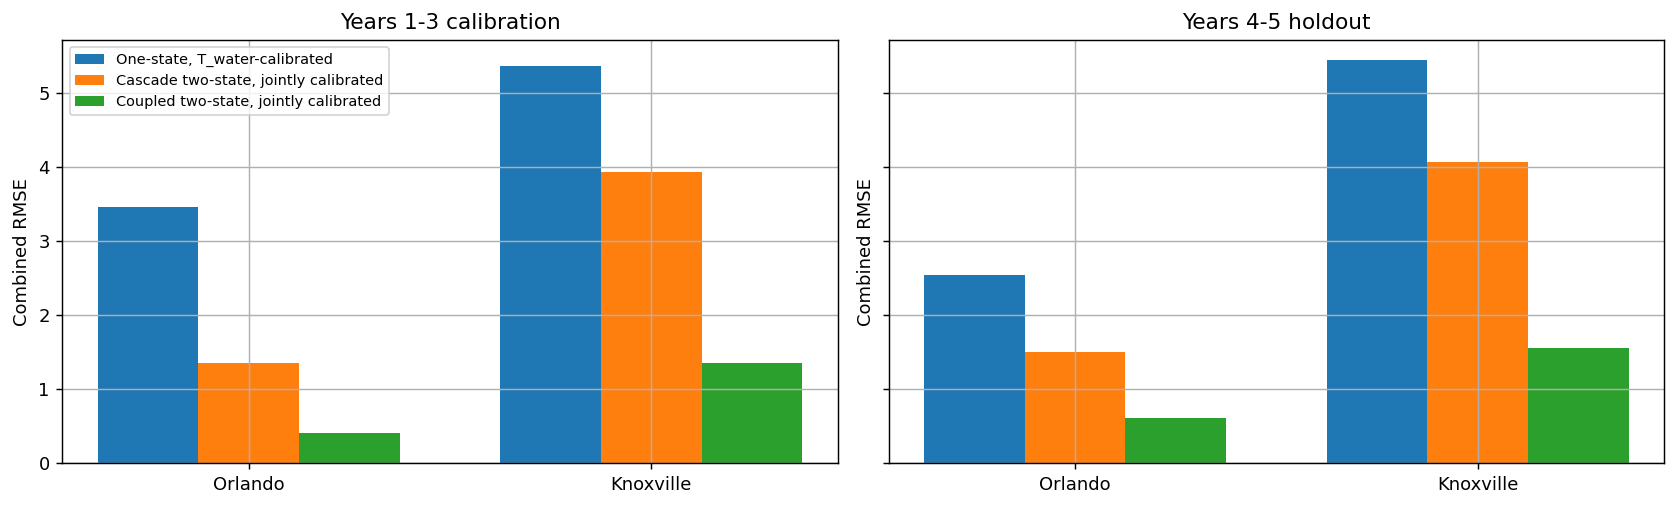

Saved: /content/drive/MyDrive/Colab Notebooks/UTB_CommunityGeothermal/multicase_rom_results/fig_multicase_combined_rmse.png


In [ ]:
# ============================================================
# 10. FIGURE: MULTI-CASE COMBINED RMSE
# ============================================================

plot_df = summary_multi.dropna(subset=["Combined_RMSE"]).copy()

model_order = [
    "One-state, T_water-calibrated",
    "Cascade two-state, jointly calibrated",
    "Coupled two-state, jointly calibrated",
]

interval_order = [
    "Years 1-3 calibration",
    "Years 4-5 holdout",
]

plot_df["model"] = pd.Categorical(plot_df["model"], categories=model_order, ordered=True)
plot_df["evaluation_interval"] = pd.Categorical(
    plot_df["evaluation_interval"],
    categories=interval_order,
    ordered=True,
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)

for ax, interval in zip(axes, interval_order):
    sub = plot_df[plot_df["evaluation_interval"] == interval].copy()

    cases = list(sub["case"].unique())
    x = np.arange(len(cases))
    width = 0.25

    for j, model in enumerate(model_order):
        vals = []
        for case in cases:
            row = sub[(sub["case"] == case) & (sub["model"] == model)]
            vals.append(row["Combined_RMSE"].iloc[0] if len(row) else np.nan)

        ax.bar(
            x + (j - 1) * width,
            vals,
            width=width,
            label=model if ax is axes[0] else None,
        )

    ax.set_xticks(x)
    ax.set_xticklabels(cases)
    ax.set_title(interval)
    ax.set_ylabel("Combined RMSE")
    ax.grid(True, axis="y")

axes[0].legend(fontsize=8, loc="best")
plt.tight_layout()

fig_path = os.path.join(OUT_DIR, "fig_multicase_combined_rmse.png")
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", fig_path)


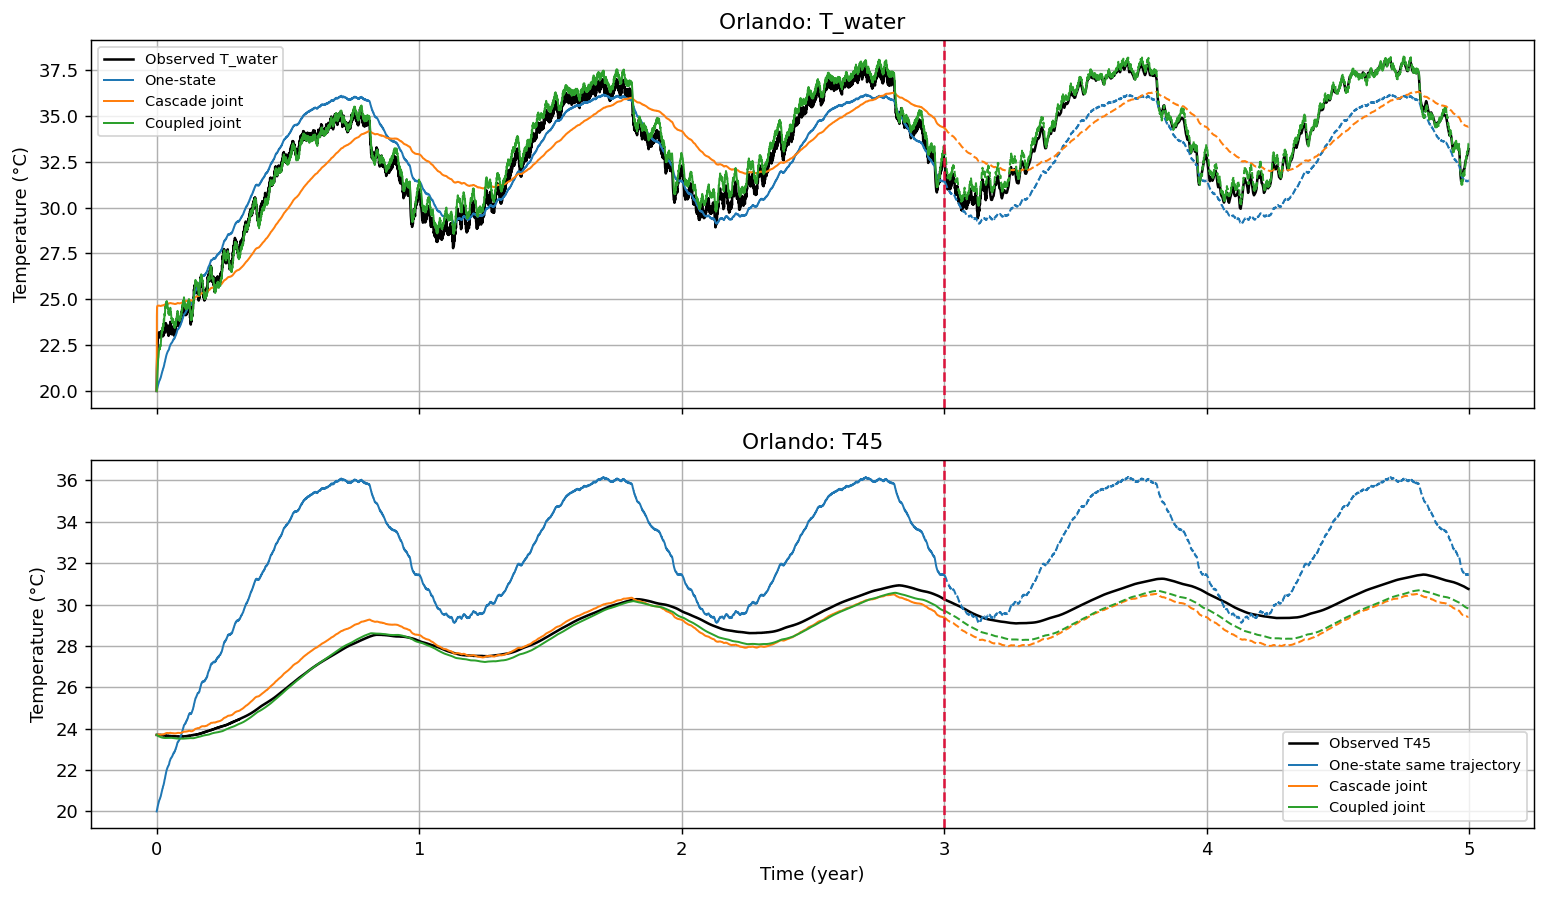

Saved: /content/drive/MyDrive/Colab Notebooks/UTB_CommunityGeothermal/multicase_rom_results/fig_trajectory_Orlando.png


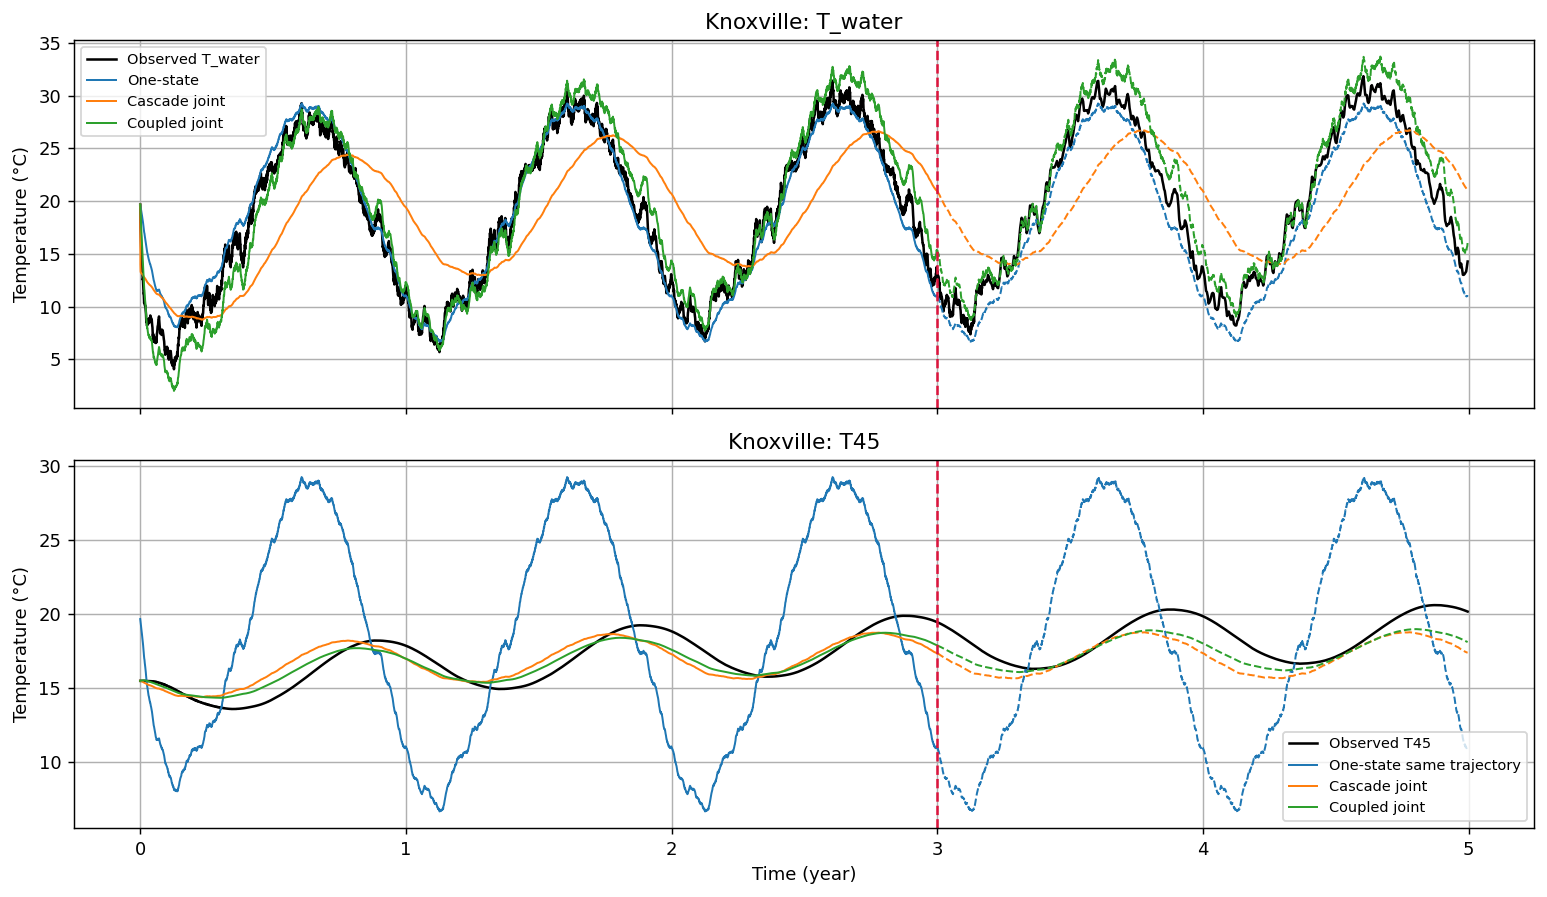

Saved: /content/drive/MyDrive/Colab Notebooks/UTB_CommunityGeothermal/multicase_rom_results/fig_trajectory_Knoxville.png


In [ ]:
# ============================================================
# 11. FIGURE: REPRESENTATIVE TRAJECTORY COMPARISON FOR EACH CASE
# ============================================================

for case in multi_results:
    res = multi_results[case]
    dcase = res["data"]
    ev = res["ev"]

    fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

    # T_water
    axes[0].plot(
        np.concatenate([dcase["tyr_c"], dcase["tyr_h"]]),
        np.concatenate([dcase["X_c"], dcase["X_h"]]),
        lw=1.4,
        label="Observed T_water",
        color="black",
    )

    axes[0].plot(dcase["tyr_c"], ev["x1c"], label="One-state", lw=1.1)
    axes[0].plot(dcase["tyr_h"], ev["x1h"], lw=1.1, ls="--", color=axes[0].lines[-1].get_color())

    axes[0].plot(dcase["tyr_c"], ev["xcj_c"], label="Cascade joint", lw=1.1)
    axes[0].plot(dcase["tyr_h"], ev["xcj_h"], lw=1.1, ls="--", color=axes[0].lines[-1].get_color())

    axes[0].plot(dcase["tyr_c"], ev["xcp_c"], label="Coupled joint", lw=1.1)
    axes[0].plot(dcase["tyr_h"], ev["xcp_h"], lw=1.1, ls="--", color=axes[0].lines[-1].get_color())

    axes[0].axvline(CALIB_YEARS, color="crimson", ls="--", lw=1.4)
    axes[0].set_ylabel("Temperature (°C)")
    axes[0].set_title(f"{case}: T_water")
    axes[0].legend(fontsize=8)

    # T45
    axes[1].plot(
        np.concatenate([dcase["tyr_c"], dcase["tyr_h"]]),
        np.concatenate([dcase["Y45_c"], dcase["Y45_h"]]),
        lw=1.4,
        label="Observed T45",
        color="black",
    )

    axes[1].plot(dcase["tyr_c"], ev["x1c"], label="One-state same trajectory", lw=1.1)
    axes[1].plot(dcase["tyr_h"], ev["x1h"], lw=1.1, ls="--", color=axes[1].lines[-1].get_color())

    axes[1].plot(dcase["tyr_c"], ev["ycj_c"], label="Cascade joint", lw=1.1)
    axes[1].plot(dcase["tyr_h"], ev["ycj_h"], lw=1.1, ls="--", color=axes[1].lines[-1].get_color())

    axes[1].plot(dcase["tyr_c"], ev["ycp_c"], label="Coupled joint", lw=1.1)
    axes[1].plot(dcase["tyr_h"], ev["ycp_h"], lw=1.1, ls="--", color=axes[1].lines[-1].get_color())

    axes[1].axvline(CALIB_YEARS, color="crimson", ls="--", lw=1.4)
    axes[1].set_xlabel("Time (year)")
    axes[1].set_ylabel("Temperature (°C)")
    axes[1].set_title(f"{case}: T45")
    axes[1].legend(fontsize=8)

    plt.tight_layout()

    fig_path = os.path.join(OUT_DIR, f"fig_trajectory_{case}.png")
    plt.savefig(fig_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved:", fig_path)


In [ ]:
# ============================================================
# 12. FINAL PRINT SUMMARY
# ============================================================

print("=" * 120)
print("MULTI-CASE ANALYSIS COMPLETE")
print("=" * 120)

print("\nPerformance summary:")
display(summary_multi)

print("\nParameter summary:")
display(params_multi)

print("\nFiles saved in:")
print(OUT_DIR)

print("\nImportant output files:")
print("- multi_case_performance_summary.csv")
print("- multi_case_parameter_summary.csv")
print("- table_multicase_performance.csv")
print("- table_multicase_holdout_performance.csv")
print("- fig_multicase_combined_rmse.png")
print("- fig_trajectory_Orlando.png")
print("- fig_trajectory_Knoxville.png")


MULTI-CASE ANALYSIS COMPLETE

Performance summary:


,case,model,evaluation_interval,RMSE_Twater,MAE_Twater,R2_Twater,RMSE_T45,MAE_T45,R2_T45,Combined_RMSE,sigma_percent,objective,p1,p2,p3,p4,p5
0,Orlando,"One-state, T_water-calibrated",Years 1-3 calibration,1.088061,0.934491,0.901812,4.777968,4.198270,-4.564104,3.465029,3.532215e-07,0.098188,2.296121e-07,1.493339e+00,0.146970,NaN,NaN
1,Orlando,"One-state, T_water-calibrated",Years 4-5 holdout,1.581722,1.456323,0.615829,3.231760,2.632953,-17.416956,2.544221,3.532215e-07,0.098188,2.296121e-07,1.493339e+00,0.146970,NaN,NaN
2,Orlando,"Cascade two-state, T_water-calibrated",Years 1-3 calibration,1.216564,1.056106,0.877250,NaN,NaN,NaN,NaN,1.155277e-06,0.122750,2.093918e-07,9.999973e-05,1.633529,0.123099,NaN
3,Orlando,"Cascade two-state, T_water-calibrated",Years 4-5 holdout,1.702746,1.541874,0.554791,NaN,NaN,NaN,NaN,1.155277e-06,0.122750,2.093918e-07,9.999973e-05,1.633529,0.123099,NaN
4,Orlando,"Cascade two-state, jointly calibrated",Years 1-3 calibration,1.847423,1.639160,0.716936,0.495426,0.415034,0.940177,1.352483,1.722397e-07,0.171443,5.950676e-08,9.999999e-05,2.367012,0.505924,NaN
5,Orlando,"Cascade two-state, jointly calibrated",Years 4-5 holdout,1.842944,1.665564,0.478459,1.047504,1.027019,-0.934865,1.498951,1.722397e-07,0.171443,5.950676e-08,9.999999e-05,2.367012,0.505924,NaN
6,Orlando,"Coupled two-state, jointly calibrated",Years 1-3 calibration,0.490702,0.422934,0.980030,0.294026,0.245523,0.978929,0.404500,7.309489e-07,0.020521,1.430643e-07,7.404148e-07,0.000002,3.033343,0.641382
7,Orlando,"Coupled two-state, jointly calibrated",Years 4-5 holdout,0.327564,0.263447,0.983524,0.793821,0.784441,-0.111181,0.607227,7.309489e-07,0.020521,1.430643e-07,7.404148e-07,0.000002,3.033343,0.641382
8,Knoxville,"One-state, T_water-calibrated",Years 1-3 calibration,1.527265,1.139638,0.955963,7.427836,6.436774,-16.483110,5.362149,1.965574e-07,0.044037,4.426002e-07,1.374387e+00,-0.014403,NaN,NaN
9,Knoxville,"One-state, T_water-calibrated",Years 4-5 holdout,1.943445,1.795861,0.925933,7.453535,6.621634,-26.039993,5.446658,1.965574e-07,0.044037,4.426002e-07,1.374387e+00,-0.014403,NaN,NaN



Parameter summary:


,case,model,k_or_c1,c2,chi,c2_over_c1,g,b,objective,sigma_percent
0,Orlando,"One-state, T_water-calibrated",2.296121e-07,NaN,NaN,NaN,1.493339,0.146970,0.098188,3.532215e-07
1,Orlando,"Cascade two-state, T_water-calibrated",2.093918e-07,9.999973e-05,NaN,477.572249,1.633529,0.123099,0.122750,1.155277e-06
2,Orlando,"Cascade two-state, jointly calibrated",5.950676e-08,9.999999e-05,NaN,1680.481180,2.367012,0.505924,0.171443,1.722397e-07
3,Orlando,"Coupled two-state, jointly calibrated",1.430643e-07,7.404148e-07,0.000002,5.175400,3.033343,0.641382,0.020521,7.309489e-07
4,Knoxville,"One-state, T_water-calibrated",4.426002e-07,NaN,NaN,NaN,1.374387,-0.014403,0.044037,1.965574e-07
5,Knoxville,"Cascade two-state, T_water-calibrated",4.099456e-07,9.999999e-05,NaN,243.934798,1.369481,-0.001920,0.027461,1.068274e-06
6,Knoxville,"Cascade two-state, jointly calibrated",4.939516e-08,9.999987e-05,NaN,2024.487008,3.186887,0.240418,0.439111,4.672135e-07
7,Knoxville,"Coupled two-state, jointly calibrated",1.265574e-07,2.942600e-07,0.000001,2.325111,6.009774,0.505256,0.112382,5.683582e-07



Files saved in:
/content/drive/MyDrive/Colab Notebooks/UTB_CommunityGeothermal/multicase_rom_results

Important output files:
- multi_case_performance_summary.csv
- multi_case_parameter_summary.csv
- table_multicase_performance.csv
- table_multicase_holdout_performance.csv
- fig_multicase_combined_rmse.png
- fig_trajectory_Orlando.png
- fig_trajectory_Knoxville.png


In [ ]:
KNOXVILLE_LOAD_PATH = os.path.join(
    BASE_DIR,
    "ppt_page24_Knoxville",
    "UTB_prop_dim.dat"
)

print("Knoxville UTB_prop_dim exists:", os.path.exists(KNOXVILLE_LOAD_PATH))

if os.path.exists(KNOXVILLE_LOAD_PATH):
    load_knx_orig = pd.read_csv(
        KNOXVILLE_LOAD_PATH,
        sep=r"\s+",
        skiprows=12,
        names=["time_s", "load"],
        usecols=[0, 1],
        engine="python",
    )

    load_knx_orig["time_s"] = pd.to_numeric(load_knx_orig["time_s"], errors="coerce")
    load_knx_orig["load"] = pd.to_numeric(load_knx_orig["load"], errors="coerce")
    load_knx_orig = load_knx_orig.dropna().reset_index(drop=True)

    knx_annual = parse_city_load_sheet_clean(LOAD_XLSX_PATH, "Knoxville")
    knx_5yr_from_xlsx = make_repeated_load_for_response(
        knx_annual,
        response_time_max_s=load_knx_orig["time_s"].max()
    )

    n = min(len(load_knx_orig), len(knx_5yr_from_xlsx))

    diff = load_knx_orig["load"].values[:n] - knx_5yr_from_xlsx["load"].values[:n]

    print("Knoxville load comparison:")
    print("n:", n)
    print("mean diff:", np.mean(diff))
    print("std diff:", np.std(diff))
    print("min diff:", np.min(diff))
    print("max diff:", np.max(diff))
    print("RMSE diff:", np.sqrt(np.mean(diff**2)))

    plt.figure(figsize=(10, 4))
    plt.plot(
        load_knx_orig["time_s"].values[:8760] / 86400,
        load_knx_orig["load"].values[:8760],
        label="Original Knoxville UTB_prop_dim.dat",
    )
    plt.plot(
        knx_5yr_from_xlsx["time_s"].values[:8760] / 86400,
        knx_5yr_from_xlsx["load"].values[:8760],
        "--",
        label="LOAD.xlsx Knoxville repeated",
    )
    plt.xlabel("Day")
    plt.ylabel("Load")
    plt.title("Knoxville load comparison, first year")
    plt.legend()
    plt.grid(True)
    plt.show()


Knoxville UTB_prop_dim exists: True


NameError: name 'make_repeated_load_for_response' is not defined